# Écologie des Maladies Infectieuses

## Problématique et Objectif du Projet

####  Contexte Écologique et Épidémiologique

L'émergence et la réémergence des maladies infectieuses sont largement influencées par les changements environnementaux et les interactions homme-animal-écosystème. La compréhension de ces dynamiques est essentielle pour la prévention et le contrôle des épidémies.

####  Problème à Résoudre

Les autorités sanitaires et les écologistes doivent identifier les zones à haut risque d'émergence de maladies infectieuses pour prioriser les interventions de surveillance et de prévention.

#### Objectif du modèle de classification :

Prédire le niveau de risque d'émergence d'une maladie infectieuse (élevé, modéré, faible) à partir de variables environnementales, climatiques, démographiques et écologiques.

#### Question de Recherche

"Quels sont les facteurs environnementaux, climatiques et écologiques qui permettent de prédire le niveau de risque d'émergence d'une maladie infectieuse dans une région donnée ?"

Utilisation par les Décideurs
Utilisateur	Application
Ministère de la Santé	Zones prioritaires pour la surveillance
Agences de protection de l'environnement	Conservation et gestion des écosystèmes
ONG sanitaires	Planification des interventions
Chercheurs	Compréhension des mécanismes d'émergence


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Fixer la graine aléatoire
np.random.seed(2025)

# --- PARAMÈTRES ---
n_observations = 10000  # Plus de 8000 lignes
n_regions = 150  # Nombre de régions uniques

# --- GÉNÉRATION DES DONNÉES ÉCOLOGIQUES ---

# 1. Variables géographiques et temporelles
regions = [f'REG_{i:04d}' for i in range(1, n_regions + 1)]
region_choices = np.random.choice(regions, n_observations, replace=True)

# Années (pour simuler des séries temporelles)
annees = np.random.choice(range(2010, 2025), n_observations, replace=True)

# Saisons
saisons = np.random.choice(['Hiver', 'Printemps', 'Été', 'Automne'], n_observations, replace=True)

# 2. Variables climatiques
# Température moyenne annuelle (°C) - entre -5 et 40°C
temperature = np.random.normal(loc=22, scale=10, size=n_observations)
temperature = np.clip(temperature, -5, 40).round(1)

# Précipitations annuelles (mm) - entre 50 et 3000 mm
precipitations = np.random.gamma(shape=2, scale=400, size=n_observations)
precipitations = np.clip(precipitations, 50, 3000).astype(int)

# Humidité relative moyenne (%) - entre 30 et 95%
humidite = np.random.normal(loc=65, scale=15, size=n_observations)
humidite = np.clip(humidite, 30, 95).astype(int)

# Amplitude thermique (°C) - entre 2 et 25°C
amplitude_thermique = np.random.gamma(shape=2, scale=5, size=n_observations)
amplitude_thermique = np.clip(amplitude_thermique, 2, 25).round(1)

# 3. Variables écologiques
# Couverture forestière (%) - entre 0 et 90%
couverture_forestiere = np.random.beta(a=2, b=3, size=n_observations) * 90
couverture_forestiere = couverture_forestiere.round(1)

# Indice de biodiversité (Shannon) - entre 0.5 et 4.0
biodiversite = np.random.gamma(shape=2, scale=0.8, size=n_observations) + 0.5
biodiversite = np.clip(biodiversite, 0.5, 4.0).round(2)

# Présence d'eau stagnante (0=Non, 1=Oui)
eau_stagnante = np.random.binomial(n=1, p=0.4, size=n_observations)

# Densité de la faune sauvage (indice 1-10)
densite_faune = np.random.poisson(lam=4, size=n_observations) + 1
densite_faune = np.clip(densite_faune, 1, 10)

# 4. Variables anthropiques
# Densité de population (habitants/km²) - entre 1 et 5000
densite_population = np.random.gamma(shape=1.5, scale=200, size=n_observations) + 1
densite_population = np.clip(densite_population, 1, 5000).astype(int)

# Indice d'urbanisation (1-10)
urbanisation = np.random.poisson(lam=3, size=n_observations) + 1
urbanisation = np.clip(urbanisation, 1, 10)

# Accès aux soins de santé (indice 1-10)
acces_soins = np.random.poisson(lam=4, size=n_observations) + 1
acces_soins = np.clip(acces_soins, 1, 10)

# Taux de déforestation (%) - entre 0 et 60%
deforestation = np.random.beta(a=1.5, b=4, size=n_observations) * 60
deforestation = deforestation.round(1)

# Indice de fragmentation de l'habitat (1-10)
fragmentation_habitat = np.random.poisson(lam=4, size=n_observations) + 1
fragmentation_habitat = np.clip(fragmentation_habitat, 1, 10)

# 5. Variables liées aux maladies
# Nombre de cas humains (simulé) - entre 0 et 500
cas_humains = np.random.negative_binomial(n=5, p=0.1, size=n_observations) * 5
cas_humains = np.clip(cas_humains, 0, 500).astype(int)

# Prévalence animale (%) - entre 0 et 40%
prevalence_animale = np.random.beta(a=2, b=8, size=n_observations) * 40
prevalence_animale = prevalence_animale.round(1)

# Nombre de réservoirs animaux connus
reservoirs_animaux = np.random.poisson(lam=3, size=n_observations)
reservoirs_animaux = np.clip(reservoirs_animaux, 0, 10)

# Taux de transmission (indice 1-10)
transmission = np.random.poisson(lam=4, size=n_observations) + 1
transmission = np.clip(transmission, 1, 10)

# 6. Variables de surveillance
# Nombre d'agents de santé par 1000 habitants
agents_sante = np.random.gamma(shape=2, scale=1.5, size=n_observations)
agents_sante = np.clip(agents_sante, 0.1, 10).round(2)

# Capacité de laboratoire (indice 1-10)
capacite_labo = np.random.poisson(lam=4, size=n_observations) + 1
capacite_labo = np.clip(capacite_labo, 1, 10)

# --- CONSTRUCTION DE LA VARIABLE CIBLE (RISQUE) ---

# Calcul du score de risque basé sur plusieurs facteurs
score_risque = (
    # Facteurs environnementaux
    + 0.6 * (temperature > 25)  # Température favorable
    + 0.5 * (humidite > 70)  # Humidité élevée
    + 0.7 * (couverture_forestiere > 50)  # Forêt dense
    + 0.8 * (eau_stagnante == 1)  # Eau stagnante
    + 0.6 * (densite_faune > 5)  # Faune abondante
    + 0.5 * (precipitations > 1500)  # Fortes précipitations
    + 0.4 * (biodiversite > 2.5)  # Biodiversité élevée
    
    # Facteurs anthropiques
    + 0.7 * (densite_population > 500)  # Densité élevée
    + 0.6 * (urbanisation > 5)  # Urbanisation
    + 0.5 * (deforestation > 20)  # Déforestation
    + 0.6 * (fragmentation_habitat > 5)  # Fragmentation
    
    # Facteurs liés aux maladies
    + 0.8 * (prevalence_animale > 20)  # Prévalence animale élevée
    + 0.7 * (reservoirs_animaux > 3)  # Réservoirs multiples
    + 0.6 * (transmission > 5)  # Transmission élevée
    + 0.4 * (cas_humains > 100)  # Cas humains
    + 0.3 * (agents_sante < 2)  # Peu d'agents de santé
    + 0.4 * (capacite_labo < 3)  # Faible capacité labo
    + 0.3 * (acces_soins < 4)  # Accès aux soins limité
)

# Ajouter du bruit aléatoire
score_risque = score_risque + np.random.normal(0, 0.3, n_observations)

# Classification du risque en 3 classes
risque = np.where(score_risque <= 3.5, 'Faible',
                  np.where(score_risque <= 6.5, 'Modéré', 'Élevé'))

# Ajouter quelques cas aléatoires pour équilibrer un peu
random_indices = np.random.choice(n_observations, size=int(n_observations * 0.1), replace=False)
for idx in random_indices:
    classes = ['Faible', 'Modéré', 'Élevé']
    probas = [0.2, 0.5, 0.3]
    risque[idx] = np.random.choice(classes, p=probas)

# --- CRÉATION DU DATAFRAME ---
df = pd.DataFrame({
    # Identifiants
    'ID': [f'ECO_{i:05d}' for i in range(1, n_observations + 1)],
    'Region': region_choices,
    'Annee': annees,
    'Saison': saisons,
    
    # Variables climatiques
    'Temperature_C': temperature,
    'Precipitations_mm': precipitations,
    'Humidite_pct': humidite,
    'Amplitude_Thermique_C': amplitude_thermique,
    
    # Variables écologiques
    'Couverture_Forestiere_pct': couverture_forestiere,
    'Biodiversite_Shannon': biodiversite,
    'Eau_Stagnante': eau_stagnante,
    'Densite_Faune': densite_faune,
    
    # Variables anthropiques
    'Densite_Population': densite_population,
    'Urbanisation': urbanisation,
    'Acces_Soins': acces_soins,
    'Deforestation_pct': deforestation,
    'Fragmentation_Habitat': fragmentation_habitat,
    
    # Variables liées aux maladies
    'Cas_Humains': cas_humains,
    'Prevalence_Animale_pct': prevalence_animale,
    'Reservoirs_Animaux': reservoirs_animaux,
    'Transmission': transmission,
    
    # Variables de surveillance
    'Agents_Sante_1000': agents_sante,
    'Capacite_Laboratoire': capacite_labo,
    
    # Variable cible
    'Risque': risque
})

# --- AJOUT DE VARIABLES DÉRIVÉES ---

# Type d'écosystème (basé sur la couverture forestière et les précipitations)
df['Type_Ecosysteme'] = np.where(
    (df['Couverture_Forestiere_pct'] > 50) & (df['Precipitations_mm'] > 1000),
    'Forêt Dense',
    np.where(
        (df['Couverture_Forestiere_pct'] > 30) & (df['Precipitations_mm'] > 500),
        'Forêt Secondaire',
        'Savane / Zone Agricole'
    )
)

# Groupe climatique
df['Groupe_Climatique'] = np.where(
    df['Temperature_C'] > 25,
    'Tropical',
    np.where(
        df['Temperature_C'] > 18,
        'Subtropical',
        'Tempéré'
    )
)

# --- SAUVEGARDE ---
df.to_csv('donnees_ecologie_maladies.csv', index=False, encoding='utf-8')

In [2]:
# --- AFFICHAGE DES INFORMATIONS ---
print("="*80)
print("🌍 JEU DE DONNÉES - ÉCOLOGIE DES MALADIES INFECTIEUSES")
print("="*80)
print(f"✅ Nombre d'observations : {len(df):,}")
print(f"✅ Nombre de variables : {len(df.columns)}")
print(f"✅ Régions représentées : {len(df['Region'].unique())}")

print("\n📊 Distribution de la variable cible (Risque) :")
print(df['Risque'].value_counts())

print("\n📋 Aperçu des données :")
print(df.head(10))

🌍 JEU DE DONNÉES - ÉCOLOGIE DES MALADIES INFECTIEUSES
✅ Nombre d'observations : 10,000
✅ Nombre de variables : 26
✅ Régions représentées : 150

📊 Distribution de la variable cible (Risque) :
Risque
Faible    6482
Modéré    3221
Élevé      297
Name: count, dtype: int64

📋 Aperçu des données :
          ID    Region  Annee     Saison  Temperature_C  Precipitations_mm  \
0  ECO_00001  REG_0063   2022        Été            7.9                 69   
1  ECO_00002  REG_0095   2019        Été           21.4                493   
2  ECO_00003  REG_0077   2022      Hiver           29.4                390   
3  ECO_00004  REG_0068   2011  Printemps           24.2               1019   
4  ECO_00005  REG_0141   2012    Automne           29.1               1183   
5  ECO_00006  REG_0023   2010    Automne           26.4                611   
6  ECO_00007  REG_0011   2019      Hiver           16.9                934   
7  ECO_00008  REG_0098   2023    Automne           17.0               1191   
8  EC

In [3]:
print("\n📊 Statistiques descriptives (variables numériques) :")
print(df.describe())


📊 Statistiques descriptives (variables numériques) :
              Annee  Temperature_C  Precipitations_mm  Humidite_pct  \
count  10000.000000   10000.000000       10000.000000  10000.000000   
mean    2016.952600      21.838480         799.210700     64.093600   
std        4.312263       9.633778         564.379119     14.680129   
min     2010.000000      -5.000000          50.000000     30.000000   
25%     2013.000000      15.200000         384.000000     54.000000   
50%     2017.000000      22.000000         663.000000     64.000000   
75%     2021.000000      28.800000        1066.000000     74.000000   
max     2024.000000      40.000000        3000.000000     95.000000   

       Amplitude_Thermique_C  Couverture_Forestiere_pct  Biodiversite_Shannon  \
count           10000.000000               10000.000000          10000.000000   
mean                9.816560                  35.807580              2.045029   
std                 6.281326                  17.970275        


📊 Statistiques descriptives (variables numériques) :
              Annee  Temperature_C  Precipitations_mm  Humidite_pct  \
count  10000.000000   10000.000000       10000.000000  10000.000000   
mean    2016.952600      21.838480         799.210700     64.093600   
std        4.312263       9.633778         564.379119     14.680129   
min     2010.000000      -5.000000          50.000000     30.000000   
25%     2013.000000      15.200000         384.000000     54.000000   
50%     2017.000000      22.000000         663.000000     64.000000   
75%     2021.000000      28.800000        1066.000000     74.000000   
max     2024.000000      40.000000        3000.000000     95.000000   

       Amplitude_Thermique_C  Couverture_Forestiere_pct  Biodiversite_Shannon  \
count           10000.000000               10000.000000          10000.000000   
mean                9.816560                  35.807580              2.045029   
std                 6.281326                  17.970275        

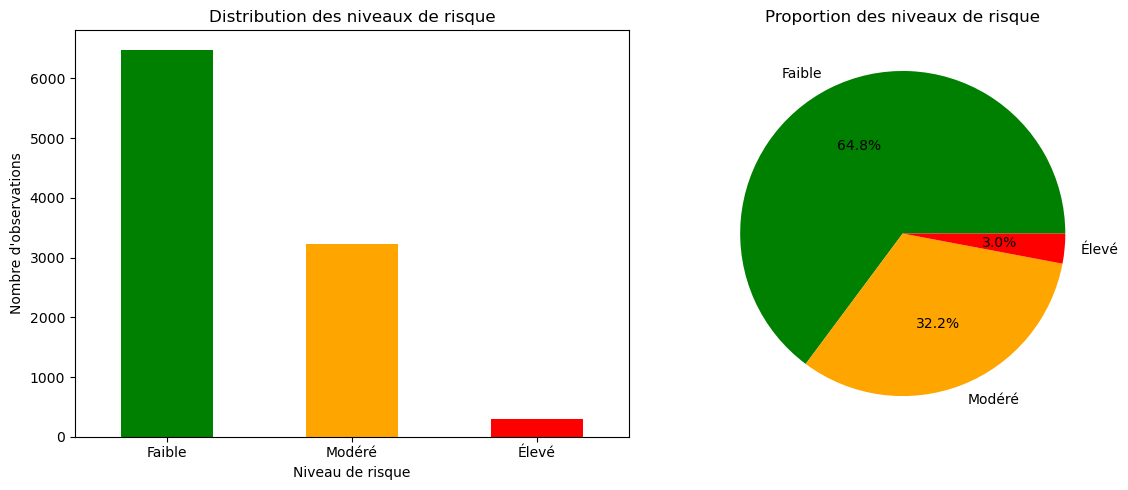

In [4]:
print("\n📊 Statistiques descriptives (variables numériques) :")
print(df.describe())

print("\n🔍 Vérification des valeurs manquantes :")
print(df.isnull().sum())

print("\n📁 Fichier sauvegardé : donnees_ecologie_maladies.csv")
print(f"💾 Taille : {len(df):,} lignes, {len(df.columns)} colonnes")

# --- ANALYSE RAPIDE ---
print("\n" + "="*80)
print("📈 ANALYSE EXPLORATOIRE RAPIDE")
print("="*80)

# Distribution de la variable cible
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = {'Faible': 'green', 'Modéré': 'orange', 'Élevé': 'red'}
df['Risque'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Distribution des niveaux de risque')
plt.xlabel('Niveau de risque')
plt.ylabel('Nombre d\'observations')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df['Risque'].value_counts().plot(kind='pie', autopct='%1.1f%%', 
                                  colors=['green', 'orange', 'red'])
plt.title('Proportion des niveaux de risque')
plt.ylabel('')

plt.tight_layout()
plt.show()

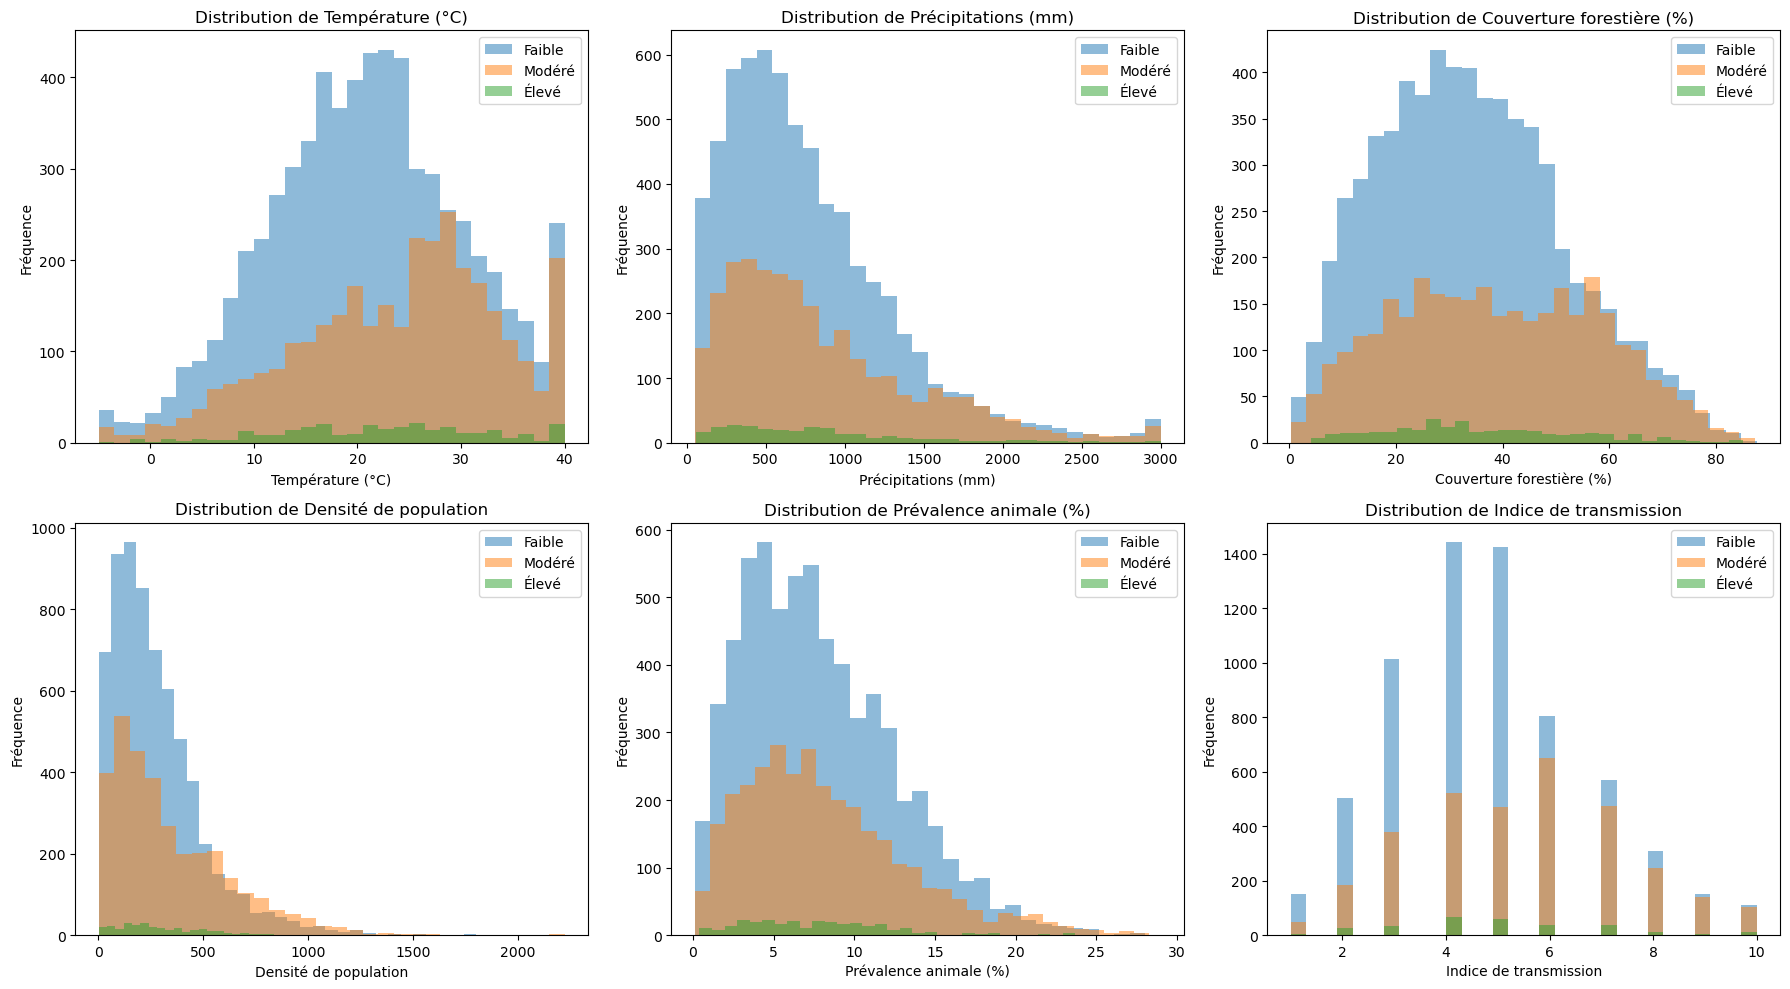

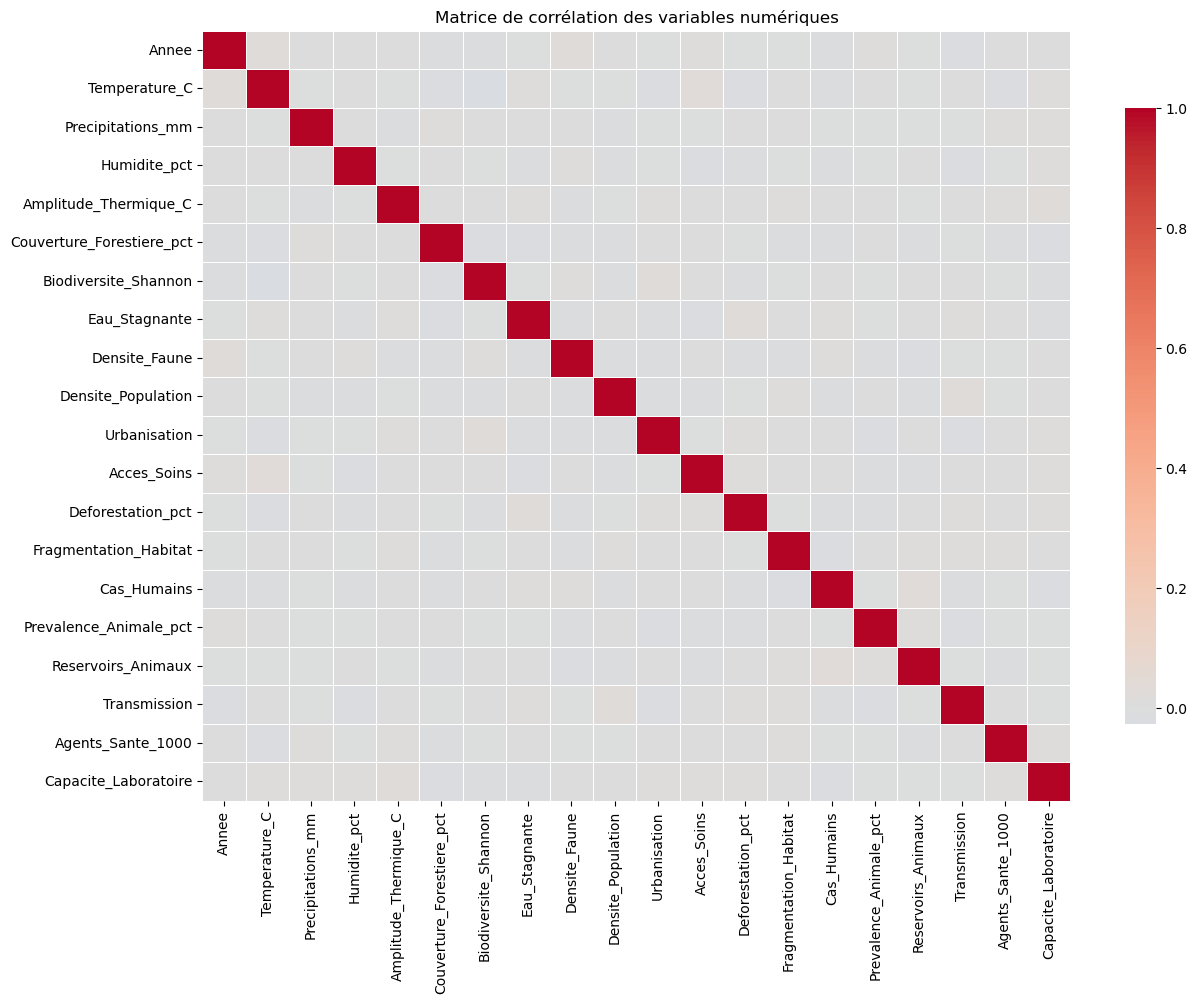

In [5]:
# Analyse des variables clés
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

variables_interessantes = [
    ('Temperature_C', 'Température (°C)'),
    ('Precipitations_mm', 'Précipitations (mm)'),
    ('Couverture_Forestiere_pct', 'Couverture forestière (%)'),
    ('Densite_Population', 'Densité de population'),
    ('Prevalence_Animale_pct', 'Prévalence animale (%)'),
    ('Transmission', 'Indice de transmission')
]

for i, (var, label) in enumerate(variables_interessantes):
    for risque_level in ['Faible', 'Modéré', 'Élevé']:
        data = df[df['Risque'] == risque_level][var]
        axes[i].hist(data, alpha=0.5, label=risque_level, bins=30)
    axes[i].set_title(f'Distribution de {label}')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Fréquence')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Matrice de corrélation
plt.figure(figsize=(14, 10))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matrice de corrélation des variables numériques')
plt.show()

Aperçu des données :
          ID    Region  Annee     Saison  Temperature_C  Precipitations_mm  \
0  ECO_00001  REG_0063   2022        Été            7.9                 69   
1  ECO_00002  REG_0095   2019        Été           21.4                493   
2  ECO_00003  REG_0077   2022      Hiver           29.4                390   
3  ECO_00004  REG_0068   2011  Printemps           24.2               1019   
4  ECO_00005  REG_0141   2012    Automne           29.1               1183   

   Humidite_pct  Amplitude_Thermique_C  Couverture_Forestiere_pct  \
0            56                    6.4                       61.1   
1            61                    3.6                       18.2   
2            69                    2.0                       35.4   
3            68                   10.9                       21.0   
4            63                   25.0                       61.0   

   Biodiversite_Shannon  ...  Fragmentation_Habitat  Cas_Humains  \
0                  2.08  ..

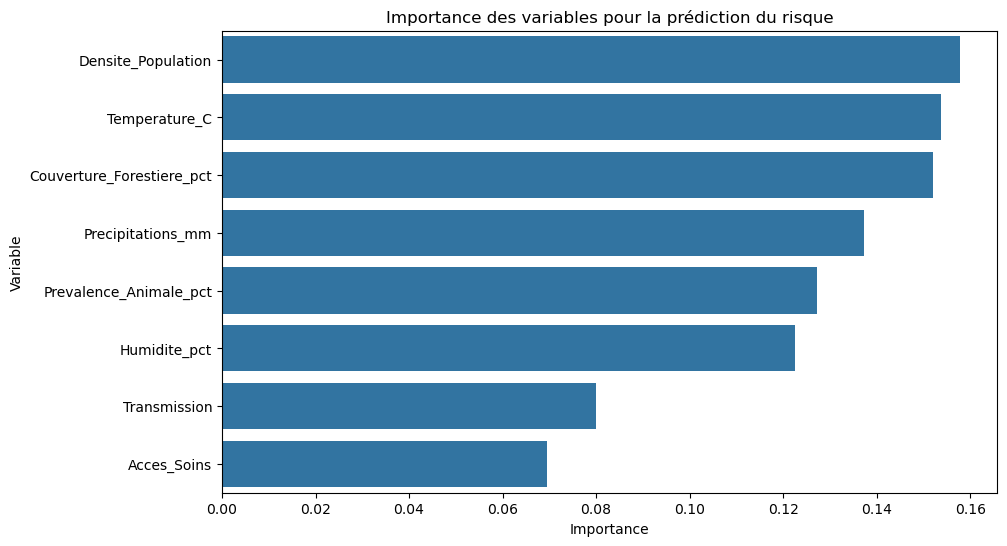

In [6]:
# --- EXEMPLE DE NOTEBOOK POUR LES ÉTUDIANTS ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Chargement des données
df = pd.read_csv('donnees_ecologie_maladies.csv')
print("Aperçu des données :")
print(df.head())

# 2. Analyse exploratoire
print("\nDistribution de la variable cible :")
print(df['Risque'].value_counts())

# 3. Prétraitement
# Encodage des variables catégorielles
le = LabelEncoder()
df['Risque_encoded'] = le.fit_transform(df['Risque'])

# Sélection des variables
features = ['Temperature_C', 'Precipitations_mm', 'Humidite_pct', 
           'Couverture_Forestiere_pct', 'Densite_Population', 
           'Prevalence_Animale_pct', 'Transmission', 'Acces_Soins']

X = df[features]
y = df['Risque_encoded']

# 4. Division train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Modèle Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# 7. Prédictions
y_pred = model.predict(X_test_scaled)

# 8. Évaluation
print("\nAccuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report :")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 9. Importance des variables
importance = pd.DataFrame({
    'Variable': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nImportance des variables :")
print(importance)

# 10. Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Variable', data=importance)
plt.title('Importance des variables pour la prédiction du risque')
plt.show()

**📧 Objet : Projet Classification - Écologie des Maladies Infectieuses**

Bonjour à tous,

Vous trouverez ci-joint le jeu de données `donnees_ecologie_maladies.csv` pour le projet de classification en écologie des maladies.

**🔬 Problématique :**

Les changements environnementaux et les interactions homme-animal-écosystème influencent l'émergence des maladies infectieuses. L'objectif est de prédire le niveau de risque d'émergence d'une maladie infectieuse dans une région donnée.

**🎯 Objectif :**

Développer un modèle de classification pour prédire le niveau de risque (Faible, Modéré, Élevé) à partir de variables environnementales, climatiques et écologiques.

**📊 Consignes :**

1. **Explorer les données** (EDA) avec visualisations
2. **Analyser les corrélations** entre les variables
3. **Prétraiter les données** (encodage, normalisation)
4. **Entraîner plusieurs modèles** de classification
5. **Comparer les performances** (accuracy, F1-score)
6. **Interpréter les résultats** en termes écologiques

**📈 Variables clés :**

- Température, précipitations, humidité
- Couverture forestière, biodiversité
- Densité de population, urbanisation
- Prévalence animale, transmission

**📝 Livrables :**

1. Notebook Jupyter complet
2. Visualisations pertinentes
3. Comparaison des modèles
4. Interprétation écologique

**📅 Date de rendu :** [À définir]

Bon travail !

Cordialement,
[Votre Nom]
Professeur de Data Science - M2 Modélisation One Health